#### Data Story - Median Cost per watt as a function of time and customer type.

3) Now loading data20180105 after d_q_and_c_5.  Has extra integer field unique_id.  Removed all nulls and zero vals in cost, cpw, size_kw.

2) Revisit with cleaned up install_type from d_q_and_c_install_type.  Consolidated install_type is now i_type.

1) Before I do this I need to clean residential data.  Maybe I should look at commercial data and see if it needs it too...

In [1]:
# %load ../pycode/setup.py
# set up
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

%matplotlib inline

def ecdf(data):
    '''Compute ECDF for a one-dimensional array of measurements.'''
    n = len(data)
    x = np.sort(data)
    y = np.arange(1, n + 1) / n
    return x, y

def min015099max(series):
    ''' return list of [ min, 1%, median, 99%, max ] series values '''
    vals = list(np.percentile(series, [1.0, 50.0, 99.0]))
    vals.insert(-1, series.max())
    vals.insert(0, series.min())
    return vals

# ss = np.arange(1, 101)
# min_1_50_99_max(ss)             

def mid98(series):
    '''  return middle 98% of series '''
    bounds = series.quantile([0.01, 0.99])
    return(series[(series > bounds.values[0]) & (series < bounds.values[1])])

# ss = np.arange(1, 101)
# min_1_50_99_max(ss)


In [2]:
# load more concise dataset for exploration
dfLive = pd.read_csv('../local/data/20180105', index_col='date_installed', parse_dates=True)

In [3]:
dfLive.describe()

,Unnamed: 0,cost_per_watt,cost,size_kw,zipcode,new_constr,tracking,third_party,bipv
count,745362.000000,745362.000000,7.453620e+05,745362.000000,745362.000000,23813.0,1705.0,239541.0,3897.0
mean,372685.587388,5.863998,6.508236e+04,12.423835,69915.556705,1.0,1.0,1.0,1.0
std,215170.712433,2.026100,4.697751e+05,105.643711,36463.241927,0.0,0.0,0.0,0.0
min,0.000000,0.750000,1.000000e+02,0.010000,0.000000,1.0,1.0,1.0,1.0
25%,186343.250000,4.565034,2.115000e+04,3.780000,21703.000000,1.0,1.0,1.0,1.0
50%,372685.500000,5.500000,3.031500e+04,5.550000,91381.000000,1.0,1.0,1.0,1.0
75%,559028.750000,7.050000,4.364500e+04,7.980000,93446.000000,1.0,1.0,1.0,1.0
max,745370.000000,30.000000,1.522000e+08,27600.000000,99737.000000,1.0,1.0,1.0,1.0


In [4]:
dfLive.describe(include=np.object)

,state,city,county,appraised,incentive,utility,tech,model,installer,i_type
count,745362,552240,732641,146655,552618,550246,421871,421871,470553,715437
unique,52,9488,902,1,59,363,11,2915,8164,8
top,CA,PHOENIX,Los Angeles,True,California Public Utilities Commission (Califo...,Pacific Gas & Electric Company,Poly,multiple matches,SolarCity,residential
freq,421074,8973,66702,146655,148976,112437,245998,69882,116391,664982


In [5]:
dfLive.head()

,Unnamed: 0,cost_per_watt,cost,size_kw,state,zipcode,city,county,new_constr,tracking,third_party,appraised,incentive,utility,tech,model,installer,bipv,i_type
date_installed,,,,,,,,,,,,,,,,,,,
2004-01-01,0,6.150000,4000.00,0.650,TN,37397,NaN,Marion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-01-01,1,5.740000,195000.00,34.000,MN,55407,NaN,Hennepin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,commercial
2004-01-01,2,7.388700,21944.44,2.970,CA,95616,Davis,Yolo,NaN,NaN,NaN,NaN,California Energy Commission (Emerging Renewab...,Pacific Gas & Electric Company,NaN,NaN,Davis Lumber & Hardware Co,NaN,NaN
2004-01-01,3,10.227273,27000.00,2.640,CA,92504,Riverside,Riverside,NaN,NaN,NaN,NaN,California Energy Commission (Emerging Renewab...,Southern California Edison,NaN,NaN,Future Air & Windows,NaN,NaN
2004-01-01,4,7.187847,32410.00,4.509,CA,94707,Kensington,Alameda,NaN,NaN,NaN,NaN,California Energy Commission (Emerging Renewab...,Pacific Gas & Electric Company,Poly,ND-167U1,Wencon Development,NaN,NaN


In [6]:
dfLive.tail()

,Unnamed: 0,cost_per_watt,cost,size_kw,state,zipcode,city,county,new_constr,tracking,third_party,appraised,incentive,utility,tech,model,installer,bipv,i_type
date_installed,,,,,,,,,,,,,,,,,,,
2015-12-31,745366,5.772114,15974.4,2.767513,CA,93291,Visalia,Tulare,NaN,NaN,1.0,True,California Public Utilities Commission (Non-CS...,Southern California Edison,Poly,REC260PE Z-LINK,SolarCity,NaN,residential
2015-12-31,745367,4.200000,54600.0,13.000000,CA,92065,RAMONA,San Diego,NaN,NaN,NaN,NaN,California Public Utilities Commission (Non-CS...,San Diego Gas & Electric Company,Poly,CS6P-260P,Solar West Electric,NaN,residential
2015-12-31,745368,4.199966,49442.0,11.772000,CA,92065,RAMONA,San Diego,NaN,NaN,1.0,NaN,California Public Utilities Commission (Non-CS...,San Diego Gas & Electric Company,Mono,SPR-327NE-WHT-D,Pacific Sky Solar,NaN,residential
2015-12-31,745369,3.800000,28728.0,7.560000,CA,92065,RAMONA,San Diego,NaN,NaN,NaN,NaN,California Public Utilities Commission (Non-CS...,San Diego Gas & Electric Company,Mono,LG315N1C-G4,West Coast Solar,NaN,residential
2015-12-31,745370,3.476190,19710.0,5.670000,CA,92056,OCEANSIDE,San Diego,NaN,1.0,NaN,NaN,California Public Utilities Commission (Non-CS...,San Diego Gas & Electric Company,Mono,LG315N1C-G4,Natural Energy,NaN,residential


In [7]:
# any nulls in the index (once bitten...)
dfLive.index.isnull().sum()

0

In [8]:
# show me the fields
dfLive.columns

Index(['Unnamed: 0', 'cost_per_watt', 'cost', 'size_kw', 'state', 'zipcode',
       'city', 'county', 'new_constr', 'tracking', 'third_party', 'appraised',
       'incentive', 'utility', 'tech', 'model', 'installer', 'bipv', 'i_type'],
      dtype='object')

In [9]:
# any nulls in row_id
dfLive['Unnamed: 0'].isnull().sum()

0

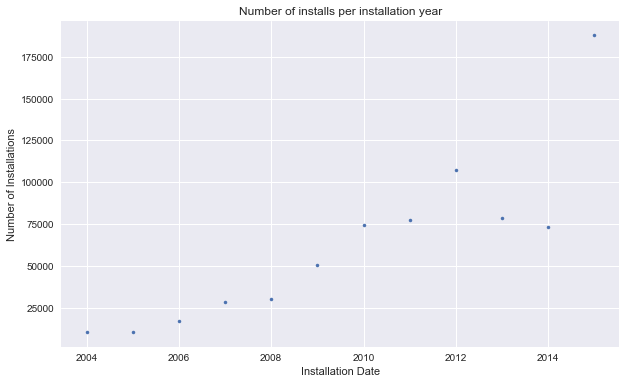

In [35]:
# check to see if it's what I think
# this has definitely changed after cleaning; there isn't a drop in installs in 13 and 14
# just lots of not so great data those years
dfLive.groupby(dfLive.index.year).size().plot(marker='.', linestyle='none')
plt.title('Number of installs per installation year')
plt.ylabel('Number of Installations')
plt.xlabel('Installation Date');

In [11]:
dfRes = dfLive.loc[dfLive.i_type == 'residential']

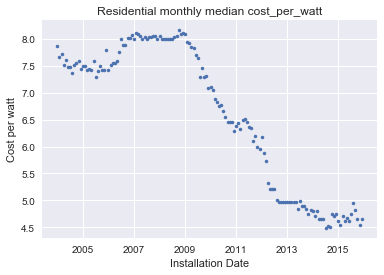

In [12]:
dfRes.resample('M')['cost_per_watt'].median().plot(marker='.', linestyle='none')
plt.title('Residential monthly median cost_per_watt')
plt.ylabel('Cost per watt')
plt.xlabel('Installation Date');

In [13]:
# this is starting to look a lot like what I need
# we needed to have a df to work with.
# dfLive.groupby(['install_type', dfLive.index.year, dfLive.index.month])['cost_per_watt'].median()
# delivers a series.  That's fine, but we need df methods to change the shape into the right form.
typeYearMonth = pd.DataFrame(dfLive.groupby(['i_type', dfLive.index.year, dfLive.index.month])['cost_per_watt'].median())
typeYearMonth.head()

cost_per_watt
i_type       date_installed date_installed               
agricultural 2004           4                        5.89
                            8                        7.60
             2005           9                        7.96
             2006           3                       11.07
                            5                        7.22

In [14]:
typeYearMonth.loc['residential'].head()

cost_per_watt
date_installed date_installed               
2004           1                        7.87
               2                        7.66
               3                        7.71
               4                        7.51
               5                        7.61

In [15]:
# okay, what I want to do is pivot the type into the columns
type(typeYearMonth)

pandas.core.frame.DataFrame

In [16]:
# year, Month in rows - cost_per_watt, i_type in columns
yearMonth_cpwType = typeYearMonth.unstack('i_type'); yearMonth_cpwType.head(15)

cost_per_watt                                    \
i_type                         agricultural commercial educational government   
date_installed date_installed                                                   
2004           1                        NaN   6.805000    9.696746        NaN   
               2                        NaN   7.562500         NaN   7.735404   
               3                        NaN   8.016250   10.017734        NaN   
               4                       5.89   7.230000    8.786111        NaN   
               5                        NaN   8.140000    8.240000   6.310000   
               6                        NaN   6.928465    7.525000   6.730000   
               7                        NaN   7.808602   10.000000        NaN   
               8                       7.60   7.788333    8.655000  15.898312   
               9                        NaN   7.390000   13.215000   9.880952   
               10                       NaN   7.981291    7.379931   9.705000   
               11                       NaN   7.512381         NaN        NaN   
               12                       NaN   7.270276    9.455694  18.998221   
2005           1                        NaN   8.000000         NaN   7.247033   
               2                        NaN   7.740000    8.530000        NaN   
               3                        NaN   7.430000   10.000000   9.888219   

                                                                         
i_type                         nonprofit residential    unknown utility  
date_installed date_installed                                            
2004           1                7.618437    7.870000        NaN     NaN  
               2               13.809524    7.660000  13.810000     NaN  
               3                     NaN    7.710000   7.690000     NaN  
               4                8.225000    7.510000   7.915000     NaN  
               5               21.980000    7.610000   7.200000     NaN  
               6                6.450000    7.470000   7.781230     NaN  
               7                8.108333    7.478095   8.640000     NaN  
               8                7.962500    7.360000   9.730000     NaN  
               9                8.986492    7.520000   8.014052     NaN  
               10                    NaN    7.540000   7.860000     NaN  
               11                    NaN    7.580000   8.000000     NaN  
               12               7.490000    7.440000   7.290000     NaN  
2005           1                9.815000    7.500000   8.278542     NaN  
               2                8.125000    7.500000   9.180000     NaN  
               3                3.270000    7.410000   8.060000     NaN

In [17]:
# the values of the index are tuples. first element is year(int), 2nd is month(int)
yearMonth_cpwType.index.get_values()[:10]

array([(2004, 1), (2004, 2), (2004, 3), (2004, 4), (2004, 5), (2004, 6),
       (2004, 7), (2004, 8), (2004, 9), (2004, 10)], dtype=object)

In [18]:
    def yearMonthTup_to_datetime(tup):
        ''' Takes a tuple of the form (year(int), month(int)); returns datetime for first of that month'''
        str = '{}{:02d}{}'.format(tup[0], tup[1], '01')
        return pd.to_datetime(str)

In [19]:
yearMonthTup_to_datetime((2004, 1))

Timestamp('2004-01-01 00:00:00')

In [20]:
# now I need to fix the index so that I can use it for plotting
# maybe just make a new column that's a datetime with year and month from existing index
dtYearMonth = yearMonth_cpwType.index.map(yearMonthTup_to_datetime)

In [21]:
# nice
dtYearMonth[:10]

DatetimeIndex(['2004-01-01', '2004-02-01', '2004-03-01', '2004-04-01',
               '2004-05-01', '2004-06-01', '2004-07-01', '2004-08-01',
               '2004-09-01', '2004-10-01'],
              dtype='datetime64[ns]', freq=None)

In [22]:
dt_cpwType = yearMonth_cpwType.set_index(dtYearMonth)

In [23]:
dt_cpwType.head()

cost_per_watt                                               \
i_type      agricultural commercial educational government  nonprofit   
2004-01-01           NaN    6.80500    9.696746        NaN   7.618437   
2004-02-01           NaN    7.56250         NaN   7.735404  13.809524   
2004-03-01           NaN    8.01625   10.017734        NaN        NaN   
2004-04-01          5.89    7.23000    8.786111        NaN   8.225000   
2004-05-01           NaN    8.14000    8.240000   6.310000  21.980000   

                                        
i_type     residential unknown utility  
2004-01-01        7.87     NaN     NaN  
2004-02-01        7.66  13.810     NaN  
2004-03-01        7.71   7.690     NaN  
2004-04-01        7.51   7.915     NaN  
2004-05-01        7.61   7.200     NaN

In [24]:
plt.rc('figure', figsize=(10, 6))

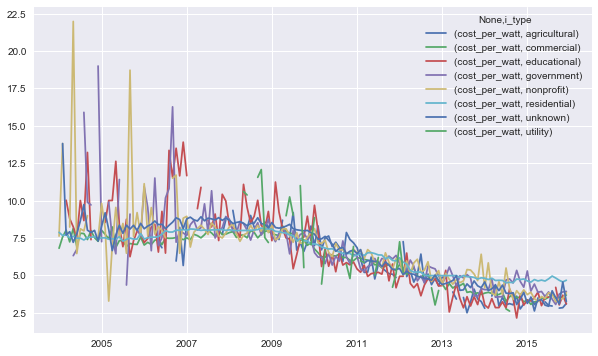

In [25]:
dt_cpwType.plot()

In [26]:
dt_cpwType.columns

MultiIndex(levels=[['cost_per_watt'], ['agricultural', 'commercial', 'educational', 'government', 'nonprofit', 'residential', 'unknown', 'utility']],
           labels=[[0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 2, 3, 4, 5, 6, 7]],
           names=[None, 'i_type'])

In [27]:
# so how do I get to my columns in this multi-index
dt_cpwType.loc[:, (slice(None), ['residential', 'commercial', 'unknown', 
                    'government', 'nonprofit', 'educational'] )].head()

cost_per_watt                                                      
i_type        commercial educational government  nonprofit residential unknown
2004-01-01       6.80500    9.696746        NaN   7.618437        7.87     NaN
2004-02-01       7.56250         NaN   7.735404  13.809524        7.66  13.810
2004-03-01       8.01625   10.017734        NaN        NaN        7.71   7.690
2004-04-01       7.23000    8.786111        NaN   8.225000        7.51   7.915
2004-05-01       8.14000    8.240000   6.310000  21.980000        7.61   7.200

In [28]:
dt_cpwType.loc[:, (slice(None), ['residential', 'commercial', 'unknown', 
                    'government', 'nonprofit', 'educational'])].tail()

cost_per_watt                                               \
i_type        commercial educational government nonprofit residential   
2015-08-01      3.706003         NaN   3.397163  3.760507    4.944088   
2015-09-01      3.499898    4.188811   3.044213  3.225813    4.814330   
2015-10-01      3.535391    3.014136   3.734409  3.404698    4.661990   
2015-11-01      3.531926    3.665946   3.883331  3.435305    4.550795   
2015-12-01      3.676716    3.077250   3.916587  3.830264    4.665583   

                      
i_type       unknown  
2015-08-01  3.959575  
2015-09-01  3.500000  
2015-10-01  3.074000  
2015-11-01  4.550638  
2015-12-01  3.240146

In [29]:
# what are the value_counts again?  I may want to leave out the ones with not many installations.
dfLive.i_type.value_counts()

residential     664982
commercial       24367
unknown          15649
government        4982
nonprofit         3564
educational       1558
agricultural       274
utility             61
Name: i_type, dtype: int64

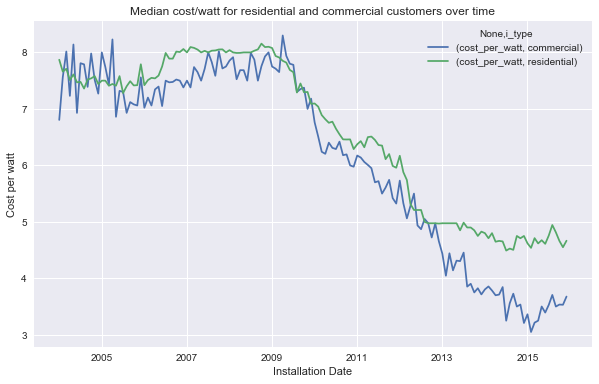

In [30]:
dt_cpwType.loc[:, (slice(None), ['residential', 'commercial'])].plot() 
# marker='.', linestyle='none'
plt.title('Median cost/watt for residential and commercial customers over time')
plt.xlabel('Installation Date')
plt.ylabel('Cost per watt');

### What does this chart and the one above tell us?

It says:

1. cost per watt declines for all installations from 2005 to 2015.
1. cost per watt converges for all kind of customers from 2005  to 2015
2. residential customers pay more per watt than commercial customers.

#### What questions does this raise?

1. it that strictly a function of size.  
2. are commercial installations generally larger than residential installations?
3. does that vary with time?
4. what is the distribution of size by i_type?  does that vary over time?
